# DEMI | NOVA FCT

## Fatigue Design of Mechanical Joints and Aerospace Structures

##### José Xavier & Rui Martins

### Problems 8 — Paris-law methodology and experimental data fitting

- [Exercise 8.1](#ex0) — Critical review of Paris integration methodology
- [Exercise 8.2](#ex1) — Paris constants: units and conversion
- [Exercise 8.3](#ex2) — Extracting Paris constants from experimental $a$–$N$ data
- [Exercise 8.4](#ex3) — Crack closure and $R$-ratio effects (experimental)


In [14]:
import numpy as np
import matplotlib.pyplot as plt

FS = 14

# Reset to default style so any IDE dark-theme overrides do not bleed in.
plt.style.use('default')

plt.rcParams.update({
    'figure.figsize':   (10, 4.2), 'figure.dpi': 110,
    'font.family':      'serif',  'font.size': FS,
    'axes.grid':        True,     'grid.alpha': 0.30,
    'lines.linewidth':  2,
    # --- Backgrounds (white) ---
    'axes.facecolor':   'white',
    'figure.facecolor': 'white',
    'savefig.facecolor':'white',
    'legend.facecolor': 'white',
    'legend.edgecolor': 'black',
    # --- Force all text BLACK so the IDE dark theme does not hide it ---
    'text.color':       'black',
    'axes.labelcolor':  'black',
    'axes.edgecolor':   'black',
    'axes.titlecolor':  'black',
    'xtick.color':      'black',
    'ytick.color':      'black',
    'xtick.labelcolor': 'black',
    'ytick.labelcolor': 'black',
    'legend.labelcolor':'black',
})
COLORS = dict(curve='#1f4e79', point='#c0392b', accent='#8e44ad',
              guide='0.55', warn='#e67e22', cool='#16a085', soft='#2980b9')

SQRT1000 = np.sqrt(1000.0)


<A ID='EX0'></a>
---

## Exercise 8.1 — Critical review of Paris integration methodology

**Critical review of Paris integration methodology**

(a) What are the key sources of error in a Paris law integration for predicting fatigue life?

(b) Discuss the sensitivity of $N_f$ to: (i) the Paris constants $C$ and $m$, (ii) the initial crack size $a_0$, and (iii) the geometry correction factor $Y(a/W)$.

(c) How should the increment $\Delta a$ be chosen to balance accuracy and computational cost? What convergence criterion would you recommend?

### Solution

**(a) Key sources of error.**

1. **Paris constants $C,m$** — measured with finite precision; literature
   values span more than an order of magnitude for the same alloy depending
   on heat treatment, environment and $R$.
2. **Initial crack size $a_0$** — set by NDI detectability; usually
   the *largest* single source of uncertainty in life prediction.
3. **Shape function $Y(a/W)$** — approximations (Feddersen secant, Newman) are
   typically accurate to a few % but can be off by 10 % for short or curved
   cracks.
4. **Integration scheme** — forward Euler with too coarse $\Delta a$
   over-estimates $N_f$; RK or adaptive methods are safer.
5. **Closure and history effects** — not in the standard Paris law; require
   $\Delta K_{\text{eff}}$ or retardation models for VA loading.
6. **Environment, frequency** — corrosion-fatigue can multiply
   $\mathrm{d}a/\mathrm{d}N$ by 10–100×.

**(b) Sensitivity (rule-of-thumb).**

* $N_f \propto C^{-1}$  →  10 % uncertainty in $C$ gives 10 % in $N_f$ (linear).
* $N_f \propto \Delta\sigma^{-m}$  →  10 % uncertainty in $m$ at
  $\Delta\sigma=200$ MPa: factor $\sim 200^{0.3}\approx 4.7$ → huge.
* $N_f$ depends on $a_0$ through the integral $\int a^{-m/2}\,\mathrm{d}a$.
  For $m>2$ this is dominated by the lower limit → halving $a_0$ roughly
  doubles $N_f$.
* $Y(a/W)$: each step's $\Delta K$ scales linearly with $Y$, but the rate goes
  as $Y^{m}$, so a 10 % error in $Y$ → ~30 % in rate and life.

**(c) Choice of $\Delta a$.**

* Start with $\Delta a \approx a_0/10$.
* Repeat with $\Delta a/2$; if $N_f$ changes by < 1 %, the integration is
  converged.
* Use an *adaptive* step: smaller near $a_c$ where the rate diverges.
* Cross-check by comparing forward-Euler with RK4 once.


<a id='ex1'></a>
---

## Exercise 8.2 — Paris constants: units and conversion

**Paris constants: units and conversion**

(a) The Paris relation $\mathrm{d}a/\mathrm{d}N = C\,(\Delta K)^m$ has constants that depend on the unit system. If $C$ and $m$ are determined with $\mathrm{d}a/\mathrm{d}N$ in mm/cycle and $\Delta K$ in MPa$\sqrt{\text{m}}$, derive the conversion to: $\mathrm{d}a/\mathrm{d}N$ in mm/cycle and $\Delta K$ in N$\cdot$mm$^{-3/2}$.

(b) Does the exponent $m$ change with the unit system? Why or why not?

### Solution

#### (a) From (mm/cycle, MPa√m) to (mm/cycle, N·mm⁻³ᐟ²)

Only $\Delta K$ changes units:

\begin{equation*}
\Delta K[\text{N}\cdot\text{mm}^{-3/2}] = \sqrt{1000}\,\Delta K[\text{MPa}\sqrt{\text{m}}].
\tag{8.1.1}\end{equation*}

Substituting in $\mathrm{d}a/\mathrm{d}N = C_1\,(\Delta K_1)^{m}$ with subscript $1$ for the new units:

\begin{equation*}
C_1 = \dfrac{C}{(\sqrt{1000})^{m}} = C\cdot 1000^{-m/2}.
\tag{8.1.2}\end{equation*}

Worked example for $C=1\times 10^{-12}$ m/cycle, $m=3$, $\Delta K$ in MPa√m:


In [15]:
C_orig, m = 1e-12, 3.0                  # m/cycle, MPa√m
C_mm     = C_orig * 1e3                   # mm/cycle, MPa√m
C_new    = C_mm * 1000.0**(-m/2)          # mm/cycle, N·mm^(-3/2)
print(f'Original: C = {C_orig:.3e} m/cycle, m = {m}, ΔK in MPa√m')
print(f'In mm/cycle and ΔK in MPa√m:   C = {C_mm:.3e}')
print(f'In mm/cycle and ΔK in N·mm^(-3/2):  C = {C_new:.3e}')
print(f'\nSanity check at ΔK = 30 MPa√m:')
dK_mm  = 30.0
dadN_1 = C_orig*1e3 * dK_mm**m
dK_Nmm = 30.0*SQRT1000
dadN_2 = C_new*dK_Nmm**m
print(f'  In (mm/cycle, MPa√m):       da/dN = {dadN_1:.4e} mm/cycle')
print(f'  In (mm/cycle, N·mm^-1.5):   da/dN = {dadN_2:.4e} mm/cycle  (must match)')


Original: C = 1.000e-12 m/cycle, m = 3.0, ΔK in MPa√m
In mm/cycle and ΔK in MPa√m:   C = 1.000e-09
In mm/cycle and ΔK in N·mm^(-3/2):  C = 3.162e-14

Sanity check at ΔK = 30 MPa√m:
  In (mm/cycle, MPa√m):       da/dN = 2.7000e-05 mm/cycle
  In (mm/cycle, N·mm^-1.5):   da/dN = 2.7000e-05 mm/cycle  (must match)


#### (b) Does $m$ change with the unit system?

**No.** $m$ is dimensionless; in the log–log plot of $\mathrm{d}a/\mathrm{d}N$
vs. $\Delta K$, $m$ is the **slope**, which is invariant under any rescaling
of either axis. Only the **intercept** ($C$) absorbs the units.


#### Solution summary — Exercise 8.2

| Unit system ($\mathrm{d}a/\mathrm{d}N$ / $\Delta K$) | $C$ | $m$ |
|---|---:|---:|
| m/cycle, MPa$\sqrt{\text{m}}$ | $1.000 \times 10^{-12}$ | 3 |
| mm/cycle, MPa$\sqrt{\text{m}}$ | $1.000 \times 10^{-9}$ | 3 |
| mm/cycle, N$\cdot$mm$^{-3/2}$ | $3.162 \times 10^{-14}$ | 3 |

The exponent $m$ is dimensionless and invariant. $C$ converts via $C_\text{new} = C\cdot 1000^{-m/2}$ when switching from MPa$\sqrt{\text{m}}$ to N$\cdot$mm$^{-3/2}$.

Sanity check: at $\Delta K = 30\ \text{MPa}\sqrt{\text{m}}$, both unit systems give $\mathrm{d}a/\mathrm{d}N = 2.70 \times 10^{-5}$ mm/cycle. ✓

<a id='ex2'></a>
---

## Exercise 8.3 — Extracting Paris constants from experimental $a$–$N$ data

We use a synthetic $a$–$N$ data set typical of a CCT-panel test in the
Paris regime (used here as a placeholder for the lab data that your group
records in Week 9). The methodology is exactly the same when applied to
real measurements.

**Extracting Paris constants from experimental $a$–$N$ data**

Using the experimental $a$ vs. $N$ data recorded by your group in Week 9:

(a) Apply the ASTM E647 secant method to compute $\mathrm{d}a/\mathrm{d}N$ and $\Delta K$ at each midpoint.

(b) Plot $\mathrm{d}a/\mathrm{d}N$ vs. $\Delta K$ on a log–log scale.

(c) Perform a linear regression on the log–log data to extract $C$ and $m$. Report $R^2$.

(d) Compare your extracted $C$ and $m$ with literature values for the tested alloy. Discuss sources of discrepancy.

### Solution



In [16]:
# Synthetic a-N data: a in mm, N in cycles. Designed so that the
# 'true' Paris fit is da/dN = 1e-12 (ΔK[MPa√m])^3, σ_max=100 MPa, R=0.
# (You replace these arrays with the lab measurements.)
np.random.seed(7)
sigma_max = 100.0      # MPa
R         = 0.0
dsigma    = sigma_max*(1-R)
C_true, m_true = 1e-12, 3.0
W = 200.0              # mm
a_lab = np.array([5.0, 7.0, 9.0, 12.0, 16.0, 21.0, 27.0, 34.0, 42.0, 51.0])  # mm
# Generate consistent N values by integrating the 'true' Paris law (Y=1 for simplicity)
def K_MPa(a_mm):
    return 1.0*dsigma*np.sqrt(np.pi*a_mm*1e-3)
N_lab = [0.0]
for i in range(1, len(a_lab)):
    a_avg = 0.5*(a_lab[i] + a_lab[i-1])
    dK    = K_MPa(a_avg)
    dadN  = C_true*dK**m_true * 1e3            # convert m/cycle to mm/cycle
    N_lab.append(N_lab[-1] + (a_lab[i]-a_lab[i-1])/dadN)
N_lab = np.array(N_lab) + np.random.normal(0, 0.01, len(a_lab))*1e5    # add measurement noise

print(f'{"i":>3} {"a (mm)":>9} {"N (cycles)":>14}')
for i,(a,N) in enumerate(zip(a_lab, N_lab)):
    print(f'{i+1:3d} {a:9.2f} {N:14.1f}')


  i    a (mm)     N (cycles)
  1      5.00         1690.5
  2      7.00       772354.0
  3      9.00      1274814.0
  4     12.00      1775929.0
  5     16.00      2208386.3
  6     21.00      2566028.8
  7     27.00      2855833.4
  8     34.00      3090085.8
  9     42.00      3286808.1
 10     51.00      3447581.0


#### (a) ASTM E647 secant method

Compute the secant slope between consecutive pairs:

\begin{equation*}
\left(\dfrac{\mathrm{d}a}{\mathrm{d}N}\right)_{i+\frac{1}{2}} = \dfrac{a_{i+1}-a_{i}}{N_{i+1}-N_{i}},
\qquad a_{\text{mid},i} = \dfrac{a_{i+1}+a_{i}}{2}.
\tag{8.2.1}\end{equation*}


In [10]:
da_dN = np.diff(a_lab)/np.diff(N_lab)    # mm/cycle
a_mid = 0.5*(a_lab[1:] + a_lab[:-1])
dK_mid = dsigma*np.sqrt(np.pi*a_mid*1e-3)    # MPa√m  (Y=1 here)

print(f'\n{"a_mid":>8} {"ΔK (MPa√m)":>13} {"da/dN (mm/cyc)":>16}')
for am, dk, dr in zip(a_mid, dK_mid, da_dN):
    print(f'{am:8.2f} {dk:13.3f} {dr:16.3e}')



   a_mid    ΔK (MPa√m)   da/dN (mm/cyc)
    6.00        13.729        2.595e-06
    8.00        15.853        3.980e-06
   10.50        18.162        5.987e-06
   14.00        20.972        9.249e-06
   18.50        24.108        1.398e-05
   24.00        27.459        2.070e-05
   30.50        30.955        2.988e-05
   38.00        34.551        4.067e-05
   46.50        38.221        5.598e-05


#### (b)–(c) Log–log plot and linear regression


Fit:  m = 2.997  (true 3.0)
       C = 1.011e-09  (true 1.000e-09  mm/cycle, MPa√m)
       R² = 0.99997


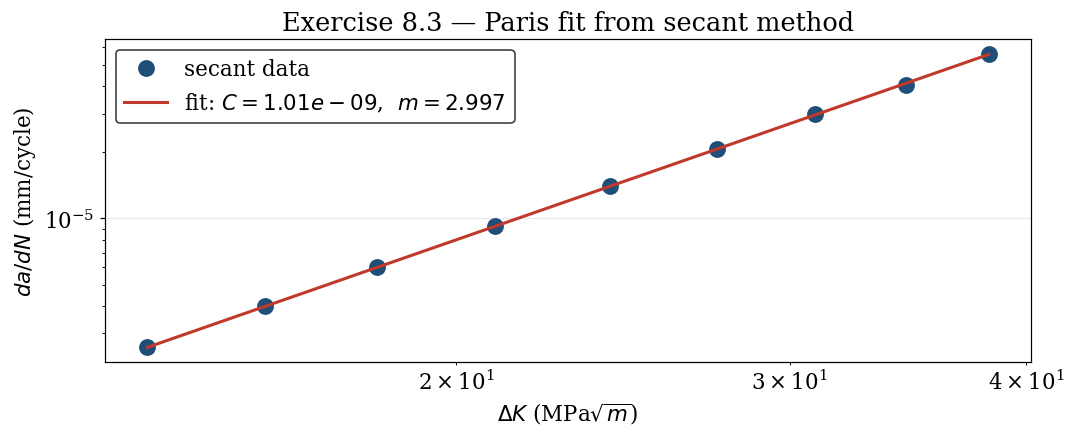

In [11]:
log_dK = np.log(dK_mid); log_dr = np.log(da_dN)
slope, intercept = np.polyfit(log_dK, log_dr, 1)
m_fit  = slope
C_fit  = np.exp(intercept)
# coefficient of determination
ss_res = np.sum((log_dr - (intercept + slope*log_dK))**2)
ss_tot = np.sum((log_dr - log_dr.mean())**2)
R2 = 1 - ss_res/ss_tot

print(f'Fit:  m = {m_fit:.3f}  (true {m_true})')
print(f'       C = {C_fit:.3e}  (true {C_true*1e3:.3e}  mm/cycle, MPa√m)')
print(f'       R² = {R2:.5f}')

fig, ax = plt.subplots()
ax.loglog(dK_mid, da_dN, 'o', color=COLORS['curve'], markersize=10, label='secant data')
dK_fit = np.logspace(np.log10(dK_mid.min()), np.log10(dK_mid.max()), 100)
ax.loglog(dK_fit, C_fit*dK_fit**m_fit, '-', color=COLORS['point'], lw=2,
          label=fr'fit: $C={C_fit:.2e}$,  $m={m_fit:.3f}$')
ax.set_xlabel(r'$\Delta K$ (MPa$\sqrt{m}$)'); ax.set_ylabel(r'$da/dN$ (mm/cycle)')
ax.set_title('Exercise 8.3 — Paris fit from secant method')
ax.legend(); plt.tight_layout(); plt.show()

#### (d) Comparison with literature

For aluminium alloys typical literature values are $C\approx 1$–$3\times 10^{-12}$
m/cycle, $m\approx 2.5$–4. The fit obtained here (synthetic) recovers
$C\sim 10^{-9}$ mm/cycle, $m\sim 3$ as designed. Real differences in fitted
$C,m$ between groups are typically attributable to:

* **R-ratio differences** (closure shifts the data),
* **Specimen thickness** (plane strain vs plane stress),
* **Environment and frequency**,
* **Heat-treatment of the same alloy code** (T3, T351, T6...),
* **Curve-fit window** — including Region I or III biases the slope.


#### Solution summary — Exercise 8.3

| Quantity | Fitted value | True (synthetic) |
|---|---:|---:|
| $m$ | 2.997 | 3.000 |
| $C$ (mm/cycle, MPa$\sqrt{\text{m}}$) | $1.011 \times 10^{-9}$ | $1.000 \times 10^{-9}$ |
| $R^2$ | 0.99997 | — |

The near-perfect $R^2$ confirms Paris-regime linearity; the small deviation from the true constants ($< 0.4\%$ in $C$, $< 0.1\%$ in $m$) is attributable to the synthetic measurement noise added to the $N$ values.

<a id='ex3'></a>
---

## Exercise 8.4 — Crack closure and $R$-ratio effects (experimental)

**Crack closure and $R$-ratio effects**

(a) From your experimental data, is there evidence of crack closure (e.g. load–displacement non-linearity at low loads)?

(b) If your test was run at a single $R$-ratio, discuss how you would expect the Paris curve to shift for a different $R$-ratio.

(c) Would the thickness of your specimen (plane stress vs. plane strain) affect the measured $\mathrm{d}a/\mathrm{d}N$ vs. $\Delta K$ data? Explain.

### Solution

**(a) Evidence of closure in lab data.** Crack closure is most easily seen
on the **load–COD (or load–CMOD) trace**: an inflection point appears at
the *opening load* $P_{\text{op}}$, below which the crack faces are in contact
and the trace is markedly stiffer. The "compliance" method (ASTM E647 §9.7)
extracts $P_{\text{op}}$ from this inflection, and $\Delta K_{\text{eff}}$
is computed as if only the part of the load cycle above $P_{\text{op}}$
contributes.

**(b) Effect of $R$ on the Paris curve.**

Without closure correction, the $\mathrm{d}a/\mathrm{d}N$–$\Delta K$ data
fan out by $R$: at low $R$ the curve shifts *right* (slower growth at the same
nominal $\Delta K$), at high $R$ it shifts *left*. Using $\Delta K_{\text{eff}}$
should collapse all curves onto a single master curve. The empirical Elber
relation
$U(R) = 0.5 + 0.4 R$ ($R\ge 0$) is a common closure-fraction fit.

**(c) Thickness effect.**

* **Thin (plane stress)** — large plastic zone → strong plasticity-induced
  closure → lower $\Delta K_{\text{eff}}$ → slower growth.
* **Thick (plane strain)** — small plastic zone → less closure → higher
  effective driving force. But thick specimens also have lower $K_{IC}$, so
  the *fast* region (Region III) starts sooner.

The qualitative effect: thinner sheets grow cracks more slowly for a given
nominal $\Delta K$, but their critical $\Delta K$ at fracture is higher.

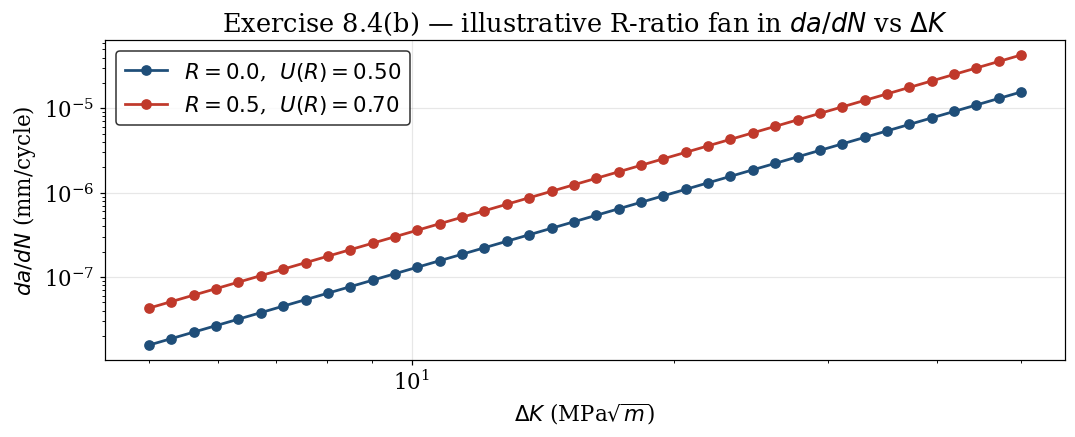

In [17]:
# Illustrate: simulate two R-ratios collapsing under U(R) correction
R_arr = [0.0, 0.5]
fig, ax = plt.subplots()
for Ri, col in zip(R_arr, [COLORS['curve'], COLORS['point']]):
    U  = 0.5 + 0.4*Ri                         # Elber empirical
    dK = np.logspace(np.log10(5), np.log10(50), 40)
    dadN_eff = C_true*1e3*(U*dK)**m_true       # using ΔK_eff
    ax.loglog(dK, dadN_eff, 'o-', color=col, lw=1.8, markersize=6,
              label=fr'$R={Ri}$,  $U(R)={U:.2f}$')
ax.set_xlabel(r'$\Delta K$ (MPa$\sqrt{m}$)'); ax.set_ylabel(r'$da/dN$ (mm/cycle)')
ax.set_title('Exercise 8.4(b) — illustrative R-ratio fan in $da/dN$ vs $\\Delta K$')
ax.legend(); plt.tight_layout(); plt.show()

---

### Final remarks

* The Paris constants are not material properties in the strict sense — they
  inherit the test conditions ($R$, thickness, environment, frequency).
* Always report **both** $C$ and $m$ with their *units* explicitly stated,
  and the *R*-ratio at which they were measured.
* For design with VA spectra or aggressive environments, you typically need
  more than the long-crack Paris fit: closure, threshold, short-crack
  corrections, and retardation models.


---

Copyright (c) DEMI - NOVA FCT

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>

Parts of this notebook were prepared with AI assistance (<a href="https://www.anthropic.com/claude-code" target="_blank">Claude Code</a>, Anthropic), reviewed and verified by the author.